# Laya: System 1 Decision Model — Experiment Notebook

**Model:** [`convaiinnovations/laya`](https://huggingface.co/convaiinnovations/laya)  
**Runs on:** Local machine, VS Code, or [Google Colab](https://colab.research.google.com/)

This notebook walks through every step of using Laya — from loading the model
with Hugging Face `transformers` to getting structured decisions on real support tickets.


## Step 1: Install Dependencies

Run this once. It installs the Hugging Face ecosystem and the `laya` decision package.


In [ ]:
!pip install laya pandas matplotlib --quiet


In [ ]:
import laya

# Load the decision model (reuses cached weights from Step 2)
agent = laya.load('convaiinnovations/laya')


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/laya/agent.py:464: RuntimeWarning: laya: this checkpoint ships invalid temperatures or values outside [0.5, 5]; using choice:11+=0.10058280825614929 -> 0.5. Treat confidence from the affected entries as uncalibrated.
  return Agent(model_id_or_path, device=device, token=token, subfolder=subfolder)


## Step 2: Define State and Questions

- **State** = the text you want to classify (a plain dict)
- **Questions** = what decisions you want, with typed schemas


In [ ]:
state = {
    'subject': 'Double charged on monthly subscription invoice #INV-88912',
    'body':    'Hello, our finance team noticed we were billed twice for April. Please refund ASAP.',
}

questions = {
    'department': {
        'type': 'choice',
        'instructions': 'Which department should handle this ticket?',
        'criteria': {
            'billing':          'Invoices, payments, double charges, refunds',
            'technical_support':'Server outages, database errors, API failures',
            'security':         'Unauthorized access, data breaches, suspicious IPs',
            'general_inquiry':  'Documentation, general questions',
        },
    },
    'urgency': {
        'type': 'score',
        'instructions': 'How urgent is this ticket?',
        'criteria': ['low', 'medium', 'high', 'critical'],
    },
    'needs_human_escalation': {
        'type': 'noul',
        'instructions': 'Does this require a human agent?',
    },
}

print('State and questions defined.')


State and questions defined.


## Step 3: Run Inference

Pass the state and questions into the model. One forward pass, ~33 ms.


In [ ]:
result  = agent.predict(state, questions)
answers = result['answers']

print('=== LAYA DECISION ===')
print(f"Department:  {answers['department']['choice']}  "
      f"({answers['department']['confidence']*100:.1f}% confidence)")
print(f"Urgency:     {answers['urgency']['score']}")
print(f"Escalate?    {answers['needs_human_escalation']['noul']}")

=== LAYA DECISION ===
Department:  billing  (90.9% confidence)
Urgency:     1.3066
Escalate?    0.726


In [ ]:
answers

{'department': {'type': 'choice',
  'choice': 'billing',
  'probabilities': {'billing': 0.9788,
   'technical_support': 0.0085,
   'security': 0.0052,
   'general_inquiry': 0.0075},
  'confidence': 0.9094,
  'action': {'act_probability': 1.0}},
 'urgency': {'type': 'score',
  'score': 1.3066,
  'legend': {'0': 'low', '1': 'medium', '2': 'high', '3': 'critical'},
  'probabilities': {'0': 0.0645, '1': 0.6431, '2': 0.2137, '3': 0.0787},
  'confidence': 0.2854,
  'action': {'act_probability': 1.0}},
 'needs_human_escalation': {'type': 'noul',
  'noul': 0.726,
  'confidence': 0.726,
  'action': {'act_probability': 1.0}}}

## Step 4: Visualize the Probability Distribution

Laya does not just return a label — it returns a **calibrated probability for every category**.


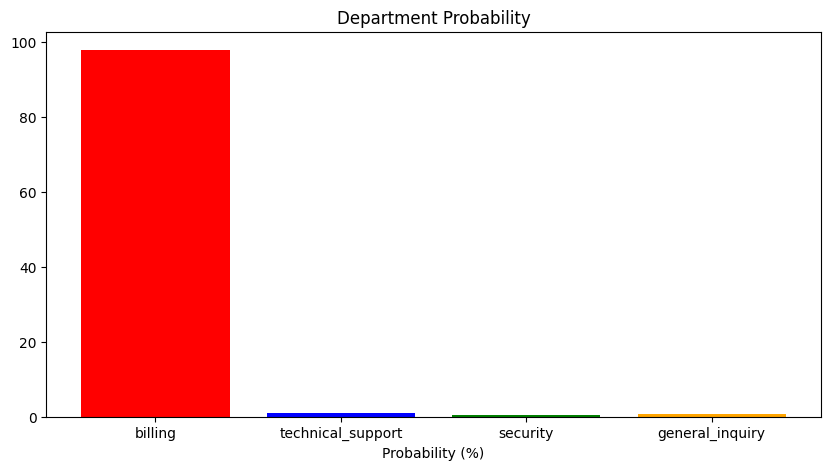

In [ ]:
import matplotlib.pyplot as plt

probs = answers['department']['probabilities']

plt.figure(figsize = (10, 5))


plt.bar(probs.keys(), [v * 100 for v in probs.values()] , color = ["red","blue","green","orange"])
plt.xlabel('Probability (%)')
plt.title('Department Probability')
plt.show()

### Interpreting the Probability Distribution

This bar chart visually represents the **calibrated probabilities** for each department. Each bar indicates the model's confidence that a given ticket belongs to a specific department.

*   **Longer bars** signify a higher probability assigned by the model.
*   This allows us to see not just the top choice ('billing' in this example), but also how close other categories were, offering a more nuanced understanding of the model's decision-making process.

## Step 5: Batch Testing on Multiple Tickets

Process several tickets at once and view results as a pandas DataFrame.


In [ ]:
import pandas as pd

tickets = [
    {'id': 'TCK-001', 'subject': 'Double charged on subscription invoice'},
    {'id': 'TCK-002', 'subject': 'Database connection pool exhausted causing HTTP 500'},
    {'id': 'TCK-003', 'subject': 'Unrecognized login from foreign IP — possible breach'},
    {'id': 'TCK-004', 'subject': 'How do I export data to CSV from the dashboard?'},
    {'id': 'TCK-005', 'subject': 'CRITICAL: Full production downtime, all services offline'},
]

rows = []
for ticket in tickets:
    state_t  = {'subject': ticket['subject'], 'body': ''}
    result_t = agent.predict(state_t, questions)
    ans_t    = result_t['answers']
    rows.append({
        'ID':         ticket['id'],
        'Subject':    ticket['subject'][:48],
        'Department': ans_t['department']['choice'],
        'Confidence': f"{ans_t['department']['confidence']*100:.1f}%",
        'Urgency':    ans_t['urgency']['score'],
        'Escalate':   ans_t['needs_human_escalation']['noul'],
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

     ID                                          Subject        Department Confidence  Urgency  Escalate
TCK-001           Double charged on subscription invoice           billing      79.7%   0.9860    0.1228
TCK-002 Database connection pool exhausted causing HTTP  technical_support      32.2%   1.2817    0.0982
TCK-003 Unrecognized login from foreign IP — possible br          security      52.8%   1.2283    0.0765
TCK-004  How do I export data to CSV from the dashboard? technical_support      16.1%   0.7829    0.0712
TCK-005 CRITICAL: Full production downtime, all services technical_support      67.6%   2.9781    0.0835
